## Loading & Pre-Processing Data

#### 1. Importing the Images

The first dataset, from Kaggle, consists of about 8,000 samples of solar flares

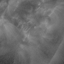

In [2]:
import os
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

IMG = 64

def load_gray(path):
    img = Image.open(path).resize((IMG, IMG))
    return img

img1 = load_gray('data\\training\\11388\\2012_01_07_02_27_01_0\\2012-01-06T142701__94.jpg')
display(img1)

### Loading a Set of Images
This function loads a set of images from the dataset. Giving it a sample number will return the target (peak emission) and the relevant images. If images are missing, they will be null with a flag.

In [3]:
import os
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

IMG = 24

# ----------------------------------------------------------------------
# STEP 3 — Turn each single image into many via data augmentation
# ----------------------------------------------------------------------
def augment(pil_img):
    """Return one randomly transformed 28x28 array in [0, 1]."""
    angle = np.random.uniform(-25, 25)                 # random rotation
    im = pil_img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
    # random shift
    dx, dy = np.random.randint(-3, 4), np.random.randint(-3, 4)
    im = im.transform((IMG, IMG), Image.AFFINE, (1, 0, dx, 0, 1, dy), fillcolor=0)
    arr = np.array(im, dtype=np.float32) / 255.0
    arr += np.random.normal(0, 0.06, arr.shape)        # random noise
    return np.clip(arr, 0, 1)

def build(pil_img, label, n):
    X = np.array([augment(pil_img) for _ in range(n)], dtype=np.float32)
    y = np.full((n, 1), label, dtype=np.float32)
    return X, y



def load_gray(path):
    img = Image.open(path).resize((IMG, IMG))
    return img

def find_folder(root_dir, folder_name):
    for root, dirs, files in os.walk(root_dir):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    
    return None

    
# Either 94, 131, 171, 193, 211, 304, 335, 1700, continuum, or magnetogram
SOURCE_TYPE = "magnetogram"

# Threshold of what the model considers a solar flare.
# C-Class (10e-6 - 10e-5): Limited effects on Earth
# M-Class (10e-5 - 10e-4): Can cause radio blackouts near poles
# X-Class (>10e-4): Can cause large radio blackouts & big problems

FLARE_THRESHOLD = 1e-5


def load_image_set(sample_id):

    # Get the data directory
    data_dir = find_folder("data", str(sample_id))

    # Get all the relevant files
    relevant_files = []
    for root, dirs, files in os.walk(data_dir):
        relevant_files = [os.path.join(root, f) for f in files if SOURCE_TYPE in f]

    # Load all relevant images
    X_list = []
    y_list = []

    # Determine whether this was a solar flare
    metadata = pd.read_csv(
        os.path.join(os.path.dirname(data_dir), "meta_data.csv")
    )    

    flux = 0
    for index, row in metadata.iterrows():
        if str(sample_id) in row["id"]:
            flux = row["peak_flux"]
            break
            

    # Go through and process all the images
    for file in relevant_files:
        curr_img = load_gray(file)
        display(curr_img)
        curr_X, curr_y = build(curr_img, flux > FLARE_THRESHOLD, 200)
        X_list.append(curr_X)
        y_list.append(curr_y)

    return X_list, y_list

# Use this to get the most relevant image
X_list, y_list = load_image_set(12106)
X_augmented = X_list[0][3]
y = y_list[3]


Using device: cuda
Found 463 sample folders
Building train split...
  processed 20/324
  processed 40/324
  processed 60/324
  processed 80/324
  processed 100/324
  processed 120/324
  processed 140/324
  processed 160/324
  processed 180/324
  processed 200/324
  processed 220/324
  processed 240/324
  processed 260/324
  processed 280/324
  processed 300/324
  processed 320/324
Building val split...
  processed 20/69
  processed 40/69
  processed 60/69
Building test split...
  processed 20/70
  processed 40/70
  processed 60/70
Train: (106100, 24, 24)  Val: (10140, 24, 24)  Test: (9920, 24, 24)
Positive rate — train: 0.04147031 val: 0.031558186 test: 0.10483871
FlareCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_runnin

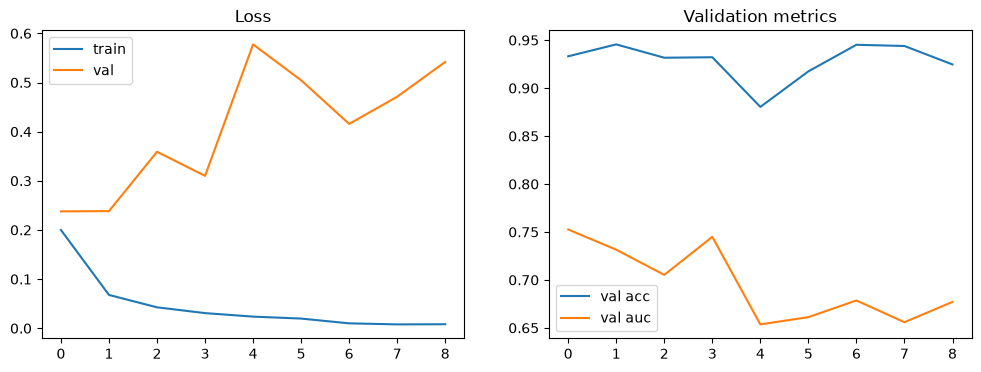

Saved model to flare_cnn.pt
Confusion matrix:
[[8711  169]
 [ 632  408]]

Classification report:
              precision    recall  f1-score   support

    No Flare       0.93      0.98      0.96      8880
       Flare       0.71      0.39      0.50      1040

    accuracy                           0.92      9920
   macro avg       0.82      0.69      0.73      9920
weighted avg       0.91      0.92      0.91      9920



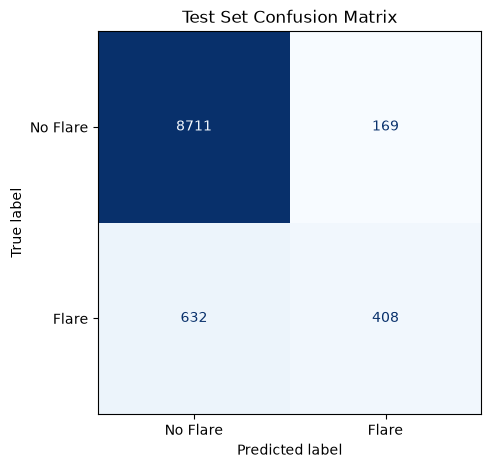

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMG = 24
SOURCE_TYPE = "magnetogram"
FLARE_THRESHOLD = 1e-5

# ----------------------------------------------------------------------
# Reuse your existing helpers
# ----------------------------------------------------------------------
def load_gray(path):
    img = Image.open(path).resize((IMG, IMG)).convert("L")
    return img

def find_folder(root_dir, folder_name):
    for root, dirs, files in os.walk(root_dir):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    return None

def augment(pil_img):
    angle = np.random.uniform(-25, 25)
    im = pil_img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
    dx, dy = np.random.randint(-3, 4), np.random.randint(-3, 4)
    im = im.transform((IMG, IMG), Image.AFFINE, (1, 0, dx, 0, 1, dy), fillcolor=0)
    arr = np.array(im, dtype=np.float32) / 255.0
    arr += np.random.normal(0, 0.06, arr.shape)
    return np.clip(arr, 0, 1)

def build(pil_img, label, n):
    X = np.array([augment(pil_img) for _ in range(n)], dtype=np.float32)
    y = np.full((n, 1), label, dtype=np.float32)
    return X, y

def load_image_set(sample_id, n_augment=50):
    data_dir = find_folder("data/training", str(sample_id))
    if data_dir is None:
        return [], []

    relevant_files = []
    for root, dirs, files in os.walk(data_dir):
        relevant_files += [os.path.join(root, f) for f in files if SOURCE_TYPE in f]

    metadata_path = os.path.join(os.path.dirname(data_dir), "meta_data.csv")
    if not os.path.exists(metadata_path):
        return [], []
    metadata = pd.read_csv(metadata_path)

    flux = 0
    for _, row in metadata.iterrows():
        if str(sample_id) in str(row["id"]):
            flux = np.log1p(row["peak_flux"])
            break

    X_list, y_list = [], []
    for file in relevant_files:
        curr_img = load_gray(file)
        curr_X, curr_y = build(curr_img, np.log1p(flux) > FLARE_THRESHOLD, n_augment)
        X_list.append(curr_X)
        y_list.append(curr_y)

    return X_list, y_list

# ----------------------------------------------------------------------
# Build the FULL dataset across every sample folder, grouped by sample_id
# to avoid leakage between train/val/test splits
# ----------------------------------------------------------------------
TRAIN_ROOT = "data/training"

sample_ids = [d for d in os.listdir(TRAIN_ROOT)
              if os.path.isdir(os.path.join(TRAIN_ROOT, d))]
print(f"Found {len(sample_ids)} sample folders")

# Split by sample_id FIRST, then augment within each split
train_ids, temp_ids = train_test_split(sample_ids, test_size=0.3, random_state=42)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=42)

def build_split(ids, n_augment):
    Xs, ys = [], []
    for i, sample_id in enumerate(ids):
        X_list, y_list = load_image_set(sample_id, n_augment=n_augment)
        for X, y in zip(X_list, y_list):
            Xs.append(X)
            ys.append(y)
        if (i + 1) % 20 == 0:
            print(f"  processed {i + 1}/{len(ids)}")
    if not Xs:
        return np.empty((0, IMG, IMG)), np.empty((0,))
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0).ravel()
    return X, y

print("Building train split...")
X_train, y_train = build_split(train_ids, n_augment=50)
print("Building val split...")
X_val, y_val = build_split(val_ids, n_augment=20)
print("Building test split...")
X_test, y_test = build_split(test_ids, n_augment=20)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Positive rate — train:", y_train.mean(), "val:", y_val.mean(), "test:", y_test.mean())

# ----------------------------------------------------------------------
# Dataset / DataLoader
# ----------------------------------------------------------------------
class FlareDataset(Dataset):
    def __init__(self, X, y):
        # (N, H, W) -> (N, 1, H, W)
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.y = torch.from_numpy(y).float().unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FlareDataset(X_train, y_train)
val_ds = FlareDataset(X_val, y_val)
test_ds = FlareDataset(X_test, y_test)

# Handle class imbalance via weighted sampler
class_counts = np.bincount(y_train.astype(int))
class_weights_per_sample = 1.0 / class_counts[y_train.astype(int)]
sampler = WeightedRandomSampler(
    weights=class_weights_per_sample,
    num_samples=len(class_weights_per_sample),
    replacement=True,
)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------------------------------------------------
# CNN model
# ----------------------------------------------------------------------
class FlareCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(64, 64)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # raw logits — use BCEWithLogitsLoss
        return x

model = FlareCNN().to(device)
print(model)

# ----------------------------------------------------------------------
# Loss, optimizer
# ----------------------------------------------------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=4
)

# ----------------------------------------------------------------------
# AUC helper (avoids needing sklearn inside the loop on GPU tensors)
# ----------------------------------------------------------------------
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate(loader):
    model.eval()
    all_logits, all_targets = [], []
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            all_logits.append(logits.cpu())
            all_targets.append(yb.cpu())
    all_logits = torch.cat(all_logits).numpy().ravel()
    all_targets = torch.cat(all_targets).numpy().ravel()
    probs = 1 / (1 + np.exp(-all_logits))
    preds = (probs > 0.5).astype(int)
    acc = accuracy_score(all_targets, preds)
    try:
        auc = roc_auc_score(all_targets, probs)
    except ValueError:
        auc = float("nan")  # only one class present
    return total_loss / len(loader.dataset), acc, auc

# ----------------------------------------------------------------------
# Training loop with early stopping on val AUC
# ----------------------------------------------------------------------
EPOCHS = 50
PATIENCE = 8

best_val_auc = -np.inf
best_state = None
epochs_no_improve = 0

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_acc, val_auc = evaluate(val_loader)
    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | train_loss {train_loss:.4f} | "
          f"val_loss {val_loss:.4f} | val_acc {val_acc:.3f} | val_auc {val_auc:.3f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Restore best weights
if best_state is not None:
    model.load_state_dict(best_state)

# ----------------------------------------------------------------------
# Test evaluation
# ----------------------------------------------------------------------
test_loss, test_acc, test_auc = evaluate(test_loader)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.3f} | Test AUC: {test_auc:.3f}")

# ----------------------------------------------------------------------
# Plot training curves
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["val_acc"], label="val acc")
axes[1].plot(history["val_auc"], label="val auc")
axes[1].set_title("Validation metrics")
axes[1].legend()
plt.show()

# ----------------------------------------------------------------------
# Save model
# ----------------------------------------------------------------------
torch.save(model.state_dict(), "flare_cnn.pt")
print("Saved model to flare_cnn.pt")

# ----------------------------------------------------------------------
# Confusion matrix
# ----------------------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def get_predictions(loader):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.append(probs)
            all_targets.append(yb.numpy().ravel())
    return np.concatenate(all_probs), np.concatenate(all_targets)

test_probs, test_targets = get_predictions(test_loader)
test_preds = (test_probs > 0.5).astype(int)

cm = confusion_matrix(test_targets, test_preds)
print("Confusion matrix:")
print(cm)
print()
print("Classification report:")
print(classification_report(test_targets, test_preds, target_names=["No Flare", "Flare"]))

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Flare", "Flare"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()